Dataset Shape:
(260, 16)

First 5 Rows:
  store_week_id city_tier region  store_format week_start_date  \
0       T11-001    Tier 2   West  Neighborhood      2025-01-06   
1       T11-002    Tier 2  North  Neighborhood      2025-01-13   
2       T11-003    Tier 2  South   High Street      2025-01-20   
3       T11-004    Tier 3   East   High Street      2025-01-27   
4       T11-005    Tier 3  North   High Street      2025-02-03   

   store_size_sqft  weekly_footfall  digital_ad_spend_k  \
0             1218             2001                48.6   
1             1363             2860                30.3   
2             1352             2434                65.8   
3              905             2262                29.2   
4             1025             2122                49.5   

   local_influencer_posts  promo_depth_pct  shelf_display_score  \
0                       1              6.4                    2   
1                       7              6.0                   10   
2      

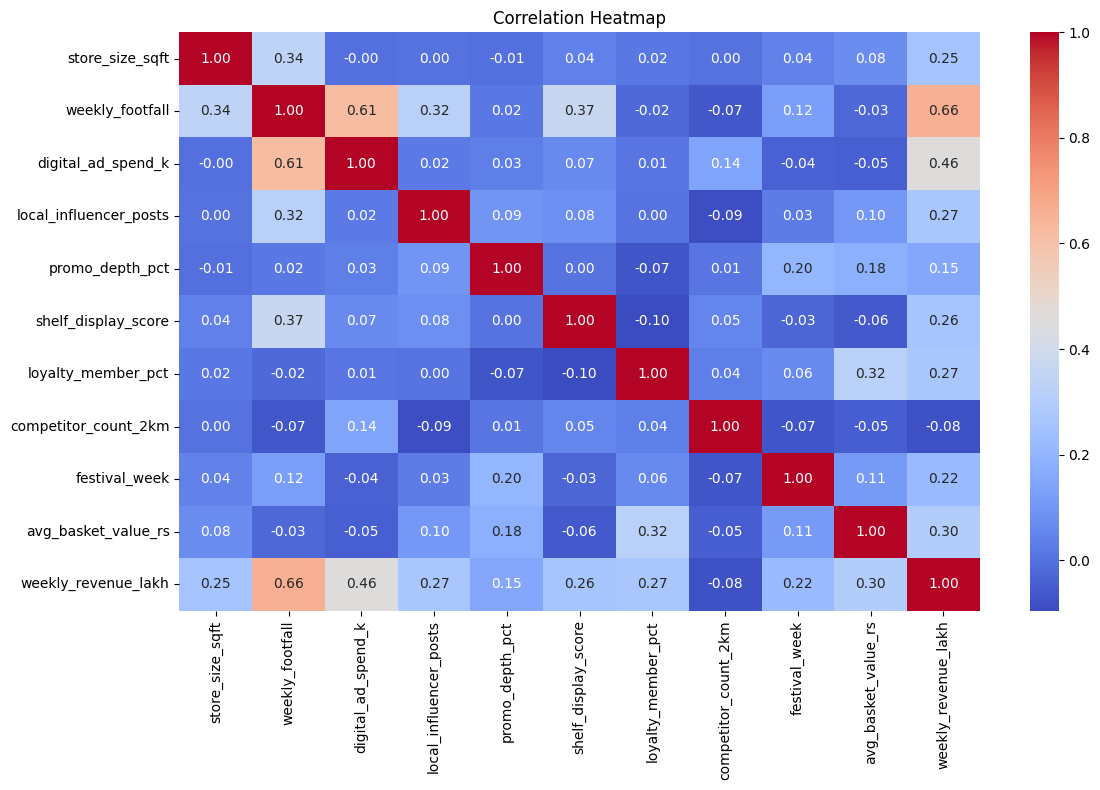


INTERPRETATION - HEATMAP
Variables with strong positive correlation
are likely to increase revenue.


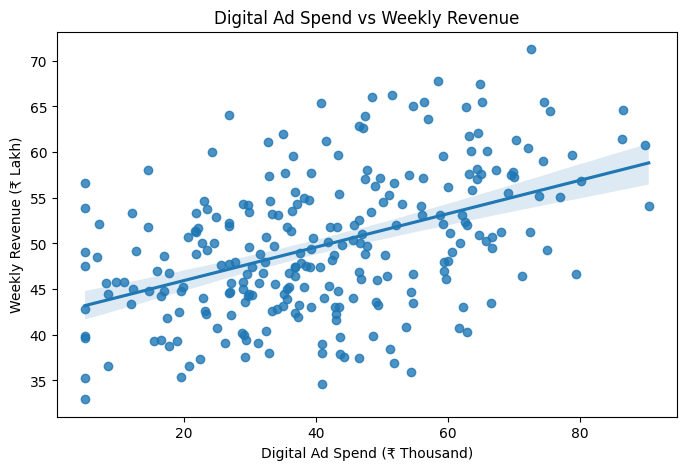


INTERPRETATION - DIGITAL ADS
An upward trend indicates that stores
spending more on digital advertising
tend to generate higher revenue.


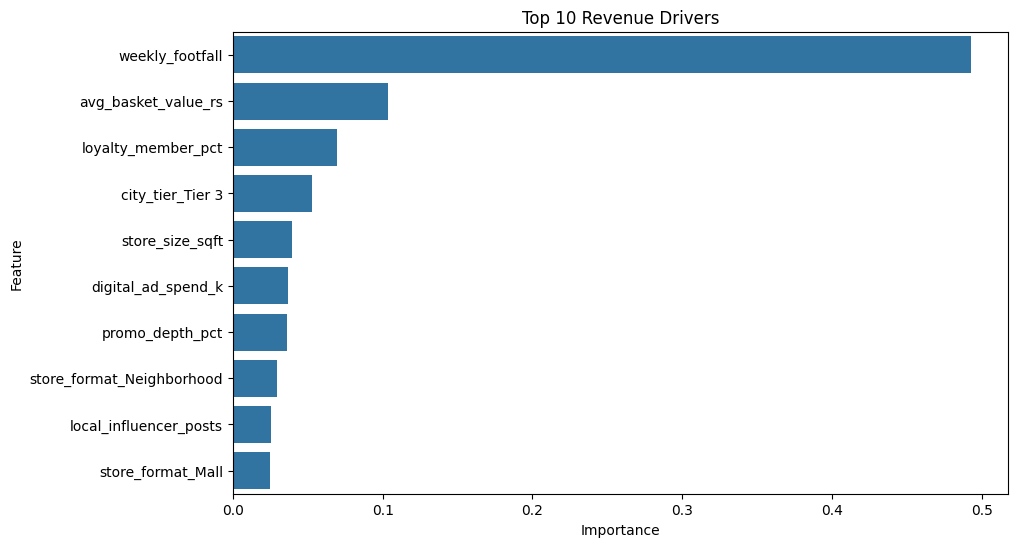


INTERPRETATION - FEATURE IMPORTANCE
Variables at the top contribute the most
towards predicting weekly revenue.

MODEL PERFORMANCE
R² Score : 0.557
RMSE : 5.096


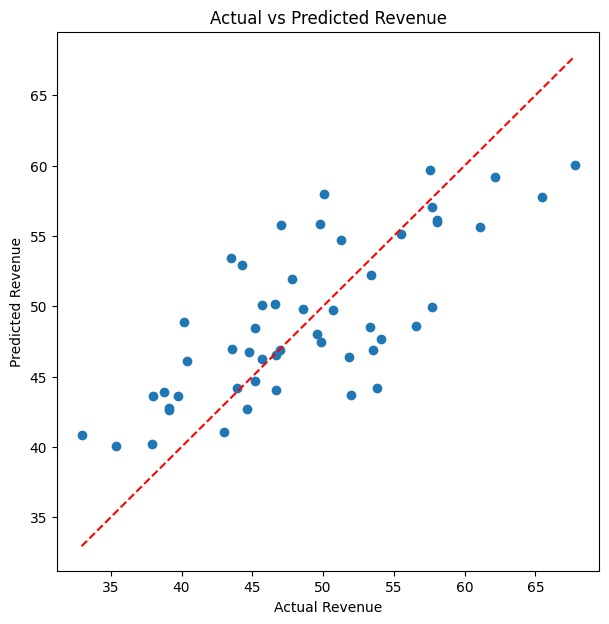


INTERPRETATION - MODEL VALIDATION
Points closer to the red line
indicate better prediction accuracy.

TOP 5 REVENUE DRIVERS
                Feature  Importance
3       weekly_footfall    0.492905
10  avg_basket_value_rs    0.103807
8    loyalty_member_pct    0.069734
12     city_tier_Tier 3    0.052963
2       store_size_sqft    0.039698

MANAGERIAL RECOMMENDATION
Focus investment on:
- weekly_footfall
- avg_basket_value_rs
- loyalty_member_pct
- city_tier_Tier 3
- store_size_sqft

These variables have the strongest
impact on weekly store revenue.


In [ ]:
# =====================================================
# RETAIL MEDIA ANALYSIS
# MULTIPLE LINEAR REGRESSION + VISUALIZATIONS
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# =====================================================
# 1. LOAD DATA
# =====================================================

df = pd.read_csv("retail_media.csv")

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nData Types:")
print(df.dtypes)

# =====================================================
# 2. HANDLE CATEGORICAL VARIABLES
# =====================================================

df_encoded = pd.get_dummies(
    df,
    columns=[
        'city_tier',
        'region',
        'store_format',
        'festival_week'
    ],
    drop_first=True,
    dtype=int
)

# =====================================================
# 3. DEFINE X AND Y
# =====================================================

y = df_encoded['weekly_revenue_lakh']

X = df_encoded.drop(
    columns=['weekly_revenue_lakh']
)

# Convert everything to numeric

X = X.apply(pd.to_numeric, errors='coerce')

# Replace missing values if any

X = X.fillna(0)

# =====================================================
# 4. MULTIPLE LINEAR REGRESSION
# =====================================================

X_const = sm.add_constant(X)

model = sm.OLS(y, X_const).fit()

print("\n================================================")
print("MULTIPLE LINEAR REGRESSION RESULTS")
print("================================================")

print(model.summary())

# =====================================================
# VISUALIZATION 1
# CORRELATION HEATMAP
# =====================================================

plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# =====================================================
# INTERPRETATION
# =====================================================

print("\nINTERPRETATION - HEATMAP")
print("Variables with strong positive correlation")
print("are likely to increase revenue.")

# =====================================================
# VISUALIZATION 2
# DIGITAL AD SPEND VS REVENUE
# =====================================================

plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x='digital_ad_spend_k',
    y='weekly_revenue_lakh'
)

plt.title("Digital Ad Spend vs Weekly Revenue")
plt.xlabel("Digital Ad Spend (₹ Thousand)")
plt.ylabel("Weekly Revenue (₹ Lakh)")
plt.show()

print("\nINTERPRETATION - DIGITAL ADS")
print("An upward trend indicates that stores")
print("spending more on digital advertising")
print("tend to generate higher revenue.")

# =====================================================
# 5. RANDOM FOREST FEATURE IMPORTANCE
# =====================================================

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

rf.fit(X,y)

importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

# =====================================================
# VISUALIZATION 3
# TOP REVENUE DRIVERS
# =====================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Revenue Drivers")
plt.show()

print("\nINTERPRETATION - FEATURE IMPORTANCE")
print("Variables at the top contribute the most")
print("towards predicting weekly revenue.")

# =====================================================
# 6. MODEL VALIDATION
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

rf.fit(X_train,y_train)

predictions = rf.predict(X_test)

r2 = r2_score(y_test,predictions)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

print("\n================================================")
print("MODEL PERFORMANCE")
print("================================================")

print("R² Score :", round(r2,3))
print("RMSE :", round(rmse,3))

# =====================================================
# VISUALIZATION 4
# ACTUAL VS PREDICTED
# =====================================================

plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    predictions
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted Revenue")

plt.show()

print("\nINTERPRETATION - MODEL VALIDATION")
print("Points closer to the red line")
print("indicate better prediction accuracy.")

# =====================================================
# TOP 5 DRIVERS
# =====================================================

print("\n================================================")
print("TOP 5 REVENUE DRIVERS")
print("================================================")

print(
    importance[
        ['Feature','Importance']
    ].head(5)
)

# =====================================================
# BUSINESS RECOMMENDATION
# =====================================================

print("\n================================================")
print("MANAGERIAL RECOMMENDATION")
print("================================================")

top5 = importance['Feature'].head(5).tolist()

print("Focus investment on:")
for i in top5:
    print("-",i)

print("\nThese variables have the strongest")
print("impact on weekly store revenue.")



TOP CONTROLLABLE MARKETING DRIVERS
                  Feature  Importance
8      loyalty_member_pct    0.069734
4      digital_ad_spend_k    0.037080
6         promo_depth_pct    0.035947
5  local_influencer_posts    0.025568
7     shelf_display_score    0.022373


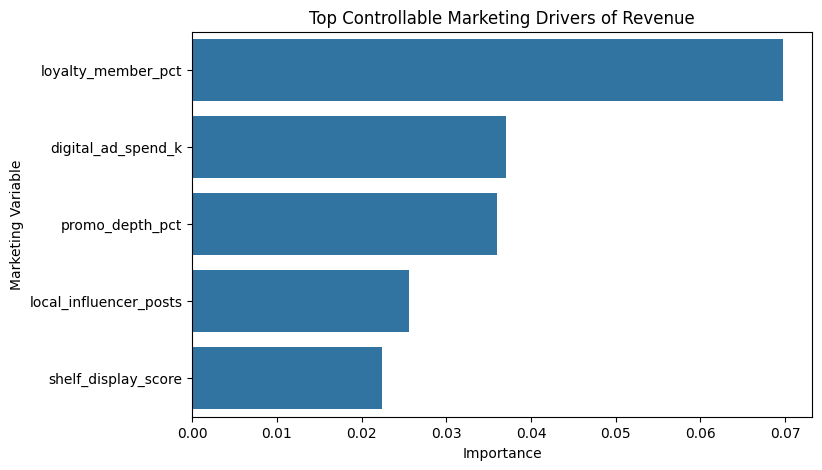



BUSINESS INTERPRETATION
1. loyalty_member_pct (Importance = 0.0697)
2. digital_ad_spend_k (Importance = 0.0371)
3. promo_depth_pct (Importance = 0.0359)
4. local_influencer_posts (Importance = 0.0256)
5. shelf_display_score (Importance = 0.0224)


MANAGERIAL INSIGHT
----------------------------------------
Loyalty programs are the strongest controllable driver of revenue.
Management should prioritize customer retention and loyalty initiatives.

Digital advertising contributes positively to revenue growth.
Promotions help but are less impactful than loyalty initiatives.
Influencer marketing supports awareness but is not a primary revenue driver.
Better shelf displays improve store performance and customer experience.


FINAL RECOMMENDATION

1. Increase investment in Loyalty Programs.
2. Continue targeted Digital Advertising.
3. Use Promotions selectively.
4. Improve Shelf Display Quality.
5. Use Influencer Marketing as a supporting channel.


Conclusion:
The analysis suggests that loy

In [ ]:
# =====================================================
# CONTROLLABLE MARKETING DRIVERS
# =====================================================

controllable_vars = [
    'digital_ad_spend_k',
    'local_influencer_posts',
    'promo_depth_pct',
    'shelf_display_score',
    'loyalty_member_pct'
]

marketing_importance = importance[
    importance['Feature'].isin(controllable_vars)
].sort_values(
    by='Importance',
    ascending=False
)

print("\n")
print("="*60)
print("TOP CONTROLLABLE MARKETING DRIVERS")
print("="*60)

print(marketing_importance)

# =====================================================
# VISUALIZATION 5
# CONTROLLABLE DRIVER IMPORTANCE
# =====================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=marketing_importance,
    x='Importance',
    y='Feature'
)

plt.title("Top Controllable Marketing Drivers of Revenue")
plt.xlabel("Importance")
plt.ylabel("Marketing Variable")

plt.show()

# =====================================================
# BUSINESS INTERPRETATION
# =====================================================

print("\n")
print("="*60)
print("BUSINESS INTERPRETATION")
print("="*60)

for rank, row in enumerate(marketing_importance.itertuples(), start=1):
    print(
        f"{rank}. {row.Feature} "
        f"(Importance = {row.Importance:.4f})"
    )

print("\n")
print("MANAGERIAL INSIGHT")
print("-"*40)

top_driver = marketing_importance.iloc[0]['Feature']

if top_driver == 'loyalty_member_pct':
    print("Loyalty programs are the strongest controllable driver of revenue.")
    print("Management should prioritize customer retention and loyalty initiatives.")

print("\nDigital advertising contributes positively to revenue growth.")
print("Promotions help but are less impactful than loyalty initiatives.")
print("Influencer marketing supports awareness but is not a primary revenue driver.")
print("Better shelf displays improve store performance and customer experience.")

print("\n")
print("="*60)
print("FINAL RECOMMENDATION")
print("="*60)

print("""
1. Increase investment in Loyalty Programs.
2. Continue targeted Digital Advertising.
3. Use Promotions selectively.
4. Improve Shelf Display Quality.
5. Use Influencer Marketing as a supporting channel.
""")

print("""
Conclusion:
The analysis suggests that loyalty building generates the highest return among controllable marketing activities. Therefore, the retail chain should prioritize loyalty programs and digital media investments before increasing promotional spending.
""")

## Retail Media Analysis Dashboard

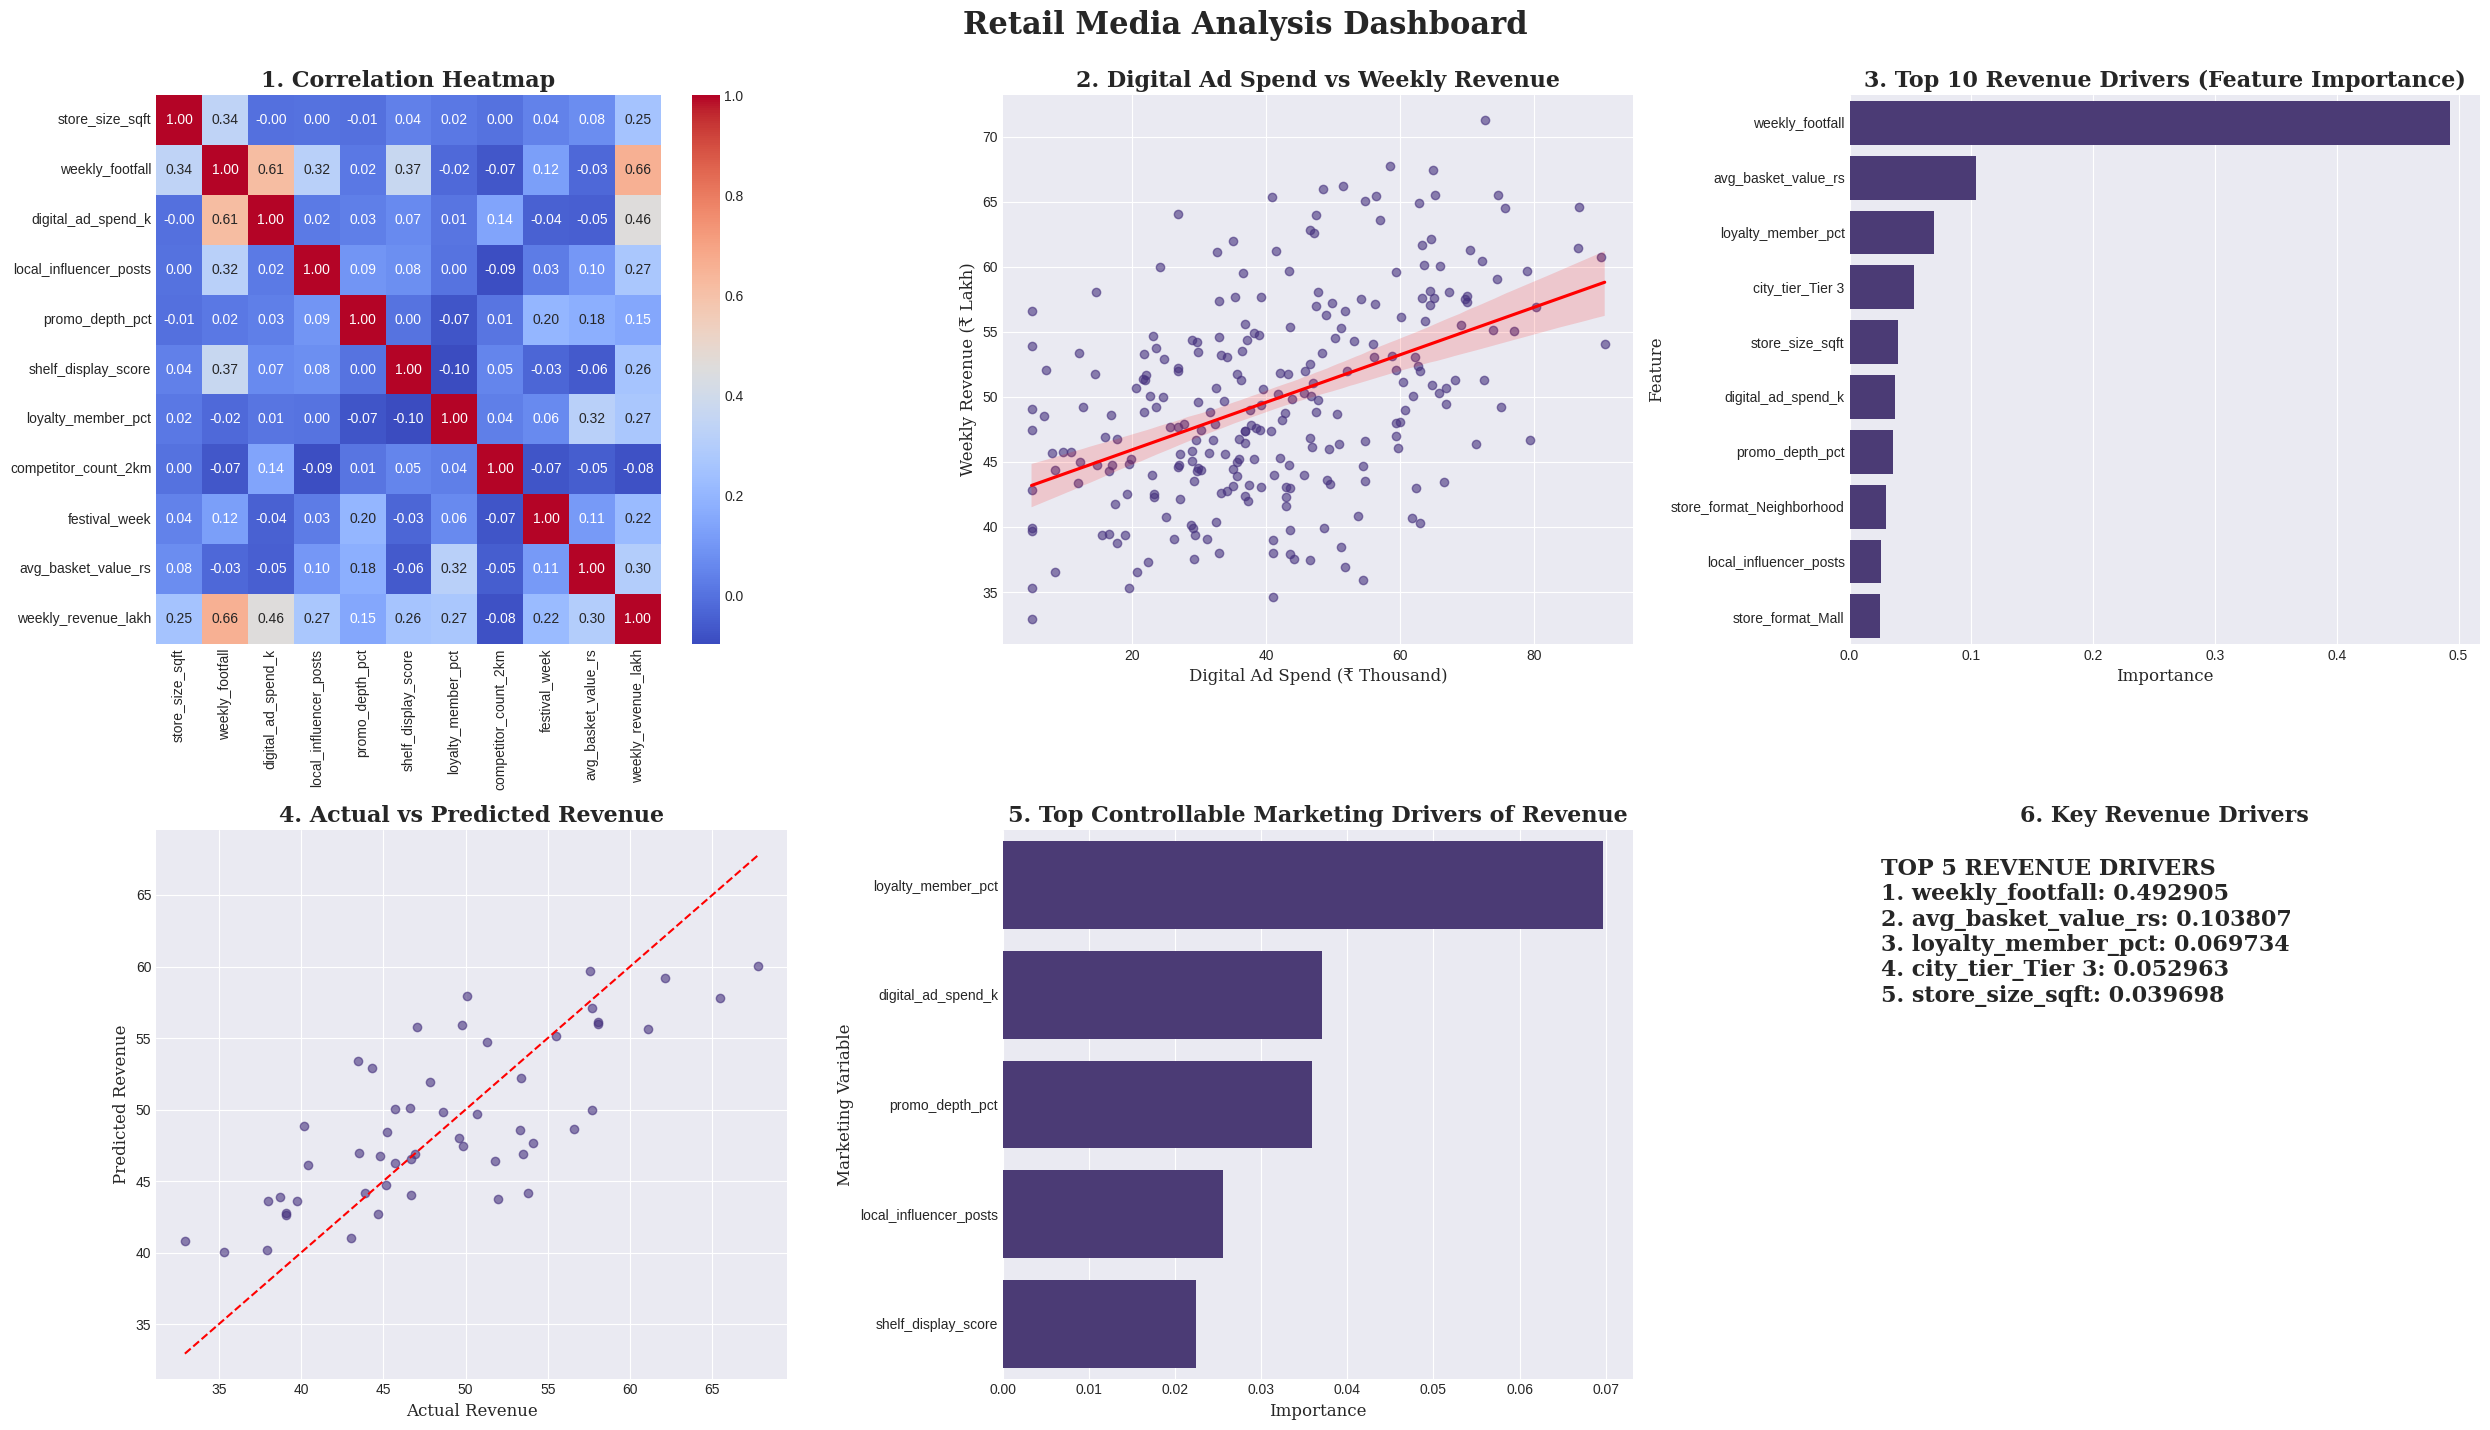

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set a professional style for all plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('viridis') # Set a consistent color palette

# Create a figure with 5 subplots (2 rows, 3 columns for landscape)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(25, 15))
axes = axes.flatten() # Flatten the 2x3 array of axes for easier iteration

# Plot 1: Correlation Heatmap
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    ax=axes[0],
    annot_kws={'fontsize': 10}
)
axes[0].set_title("1. Correlation Heatmap", fontsize=16, fontweight='bold', fontfamily='serif')
axes[0].tick_params(labelsize=10)

# Plot 2: Digital Ad Spend vs Weekly Revenue
sns.regplot(
    data=df,
    x='digital_ad_spend_k',
    y='weekly_revenue_lakh',
    ax=axes[1],
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'}
)
axes[1].set_title("2. Digital Ad Spend vs Weekly Revenue", fontsize=16, fontweight='bold', fontfamily='serif')
axes[1].set_xlabel("Digital Ad Spend (₹ Thousand)", fontsize=12, fontfamily='serif')
axes[1].set_ylabel("Weekly Revenue (₹ Lakh)", fontsize=12, fontfamily='serif')
axes[1].tick_params(labelsize=10)

# Plot 3: Top 10 Revenue Drivers (Random Forest Feature Importance)
sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature',
    ax=axes[2]
)
axes[2].set_title("3. Top 10 Revenue Drivers (Feature Importance)", fontsize=16, fontweight='bold', fontfamily='serif')
axes[2].set_xlabel("Importance", fontsize=12, fontfamily='serif')
axes[2].set_ylabel("Feature", fontsize=12, fontfamily='serif')
axes[2].tick_params(labelsize=10)

# Plot 4: Actual vs Predicted Revenue
axes[3].scatter(
    y_test,
    predictions,
    alpha=0.6
)
axes[3].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
axes[3].set_xlabel("Actual Revenue", fontsize=12, fontfamily='serif')
axes[3].set_ylabel("Predicted Revenue", fontsize=12, fontfamily='serif')
axes[3].set_title("4. Actual vs Predicted Revenue", fontsize=16, fontweight='bold', fontfamily='serif')
axes[3].tick_params(labelsize=10)

# Plot 5: Top Controllable Marketing Drivers of Revenue
sns.barplot(
    data=marketing_importance,
    x='Importance',
    y='Feature',
    ax=axes[4]
)
axes[4].set_title("5. Top Controllable Marketing Drivers of Revenue", fontsize=16, fontweight='bold', fontfamily='serif')
axes[4].set_xlabel("Importance", fontsize=12, fontfamily='serif')
axes[4].set_ylabel("Marketing Variable", fontsize=12, fontfamily='serif')
axes[4].tick_params(labelsize=10)

# Plot 6: TOP 5 REVENUE DRIVERS
axes[5].axis('off')

top_5_drivers_text = "TOP 5 REVENUE DRIVERS\n"
for i, row in enumerate(importance[['Feature', 'Importance']].head(5).iterrows()):
    top_5_drivers_text += f"{i + 1}. {row[1]['Feature']}: {row[1]['Importance']:.6f}\n"

combined_text = top_5_drivers_text

axes[5].text(0.05, 0.95, combined_text,
             horizontalalignment='left',
             verticalalignment='top',
             transform=axes[5].transAxes,
             fontsize=16,
             fontweight='bold',
             fontfamily='serif',
             wrap=True)
axes[5].set_title("6. Key Revenue Drivers", fontsize=16, fontweight='bold', fontfamily='serif')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle("Retail Media Analysis Dashboard", y=0.98, fontsize=22, fontweight='bold', fontname='serif')
plt.show()

### Dashboard Interpretation

This dashboard consolidates key insights from the retail media analysis:

1.  <h3>**Correlation Heatmap**</h3>: This visualization shows the relationships between numerical variables. Strong positive correlations (e.g., between `weekly_footfall` and `weekly_revenue_lakh`) suggest that these factors tend to move together. This helps in understanding which variables have inherent associations.

2.  <h3>**Digital Ad Spend vs Weekly Revenue**</h3>: The scatter plot with a regression line illustrates the relationship between digital advertising expenditure and weekly revenue. An upward sloping line indicates that as digital ad spend increases, weekly revenue tends to increase, highlighting the positive impact of digital marketing efforts.

3.  <h3>**Top 10 Revenue Drivers (Feature Importance)**</h3>: Derived from the Random Forest model, this bar chart identifies the most influential features in predicting weekly revenue. `weekly_footfall` and `avg_basket_value_rs` appear as the strongest drivers, followed by `loyalty_member_pct`. This prioritizes areas for strategic focus to maximize revenue.

4.  <h3>**Actual vs Predicted Revenue**</h3>: This scatter plot assesses the model's performance by comparing actual weekly revenue against the model's predictions. Points clustering closely around the red dashed line indicate high accuracy, suggesting the model is reliable in forecasting revenue.

5.  <h3>**Top Controllable Marketing Drivers of Revenue**</h3>: This bar chart specifically highlights which marketing variables, within the control of management, have the most impact on revenue. `loyalty_member_pct` stands out as the most important controllable marketing driver, followed by `digital_ad_spend_k` and `promo_depth_pct`. This insight is crucial for allocating marketing budgets and optimizing strategies.

<h3>**Overall Managerial Recommendation**</h3>: The analysis consistently points towards **loyalty programs** as the strongest controllable driver of revenue. Therefore, management should prioritize initiatives aimed at customer retention and loyalty. Continuing targeted **digital advertising** is also recommended due to its positive impact. While **promotions** are helpful, they are less impactful than loyalty initiatives. Improving **shelf display quality** and leveraging **influencer marketing** are supporting strategies that can further enhance store performance and customer engagement.

## Business Insights and Recommendations Dashboard

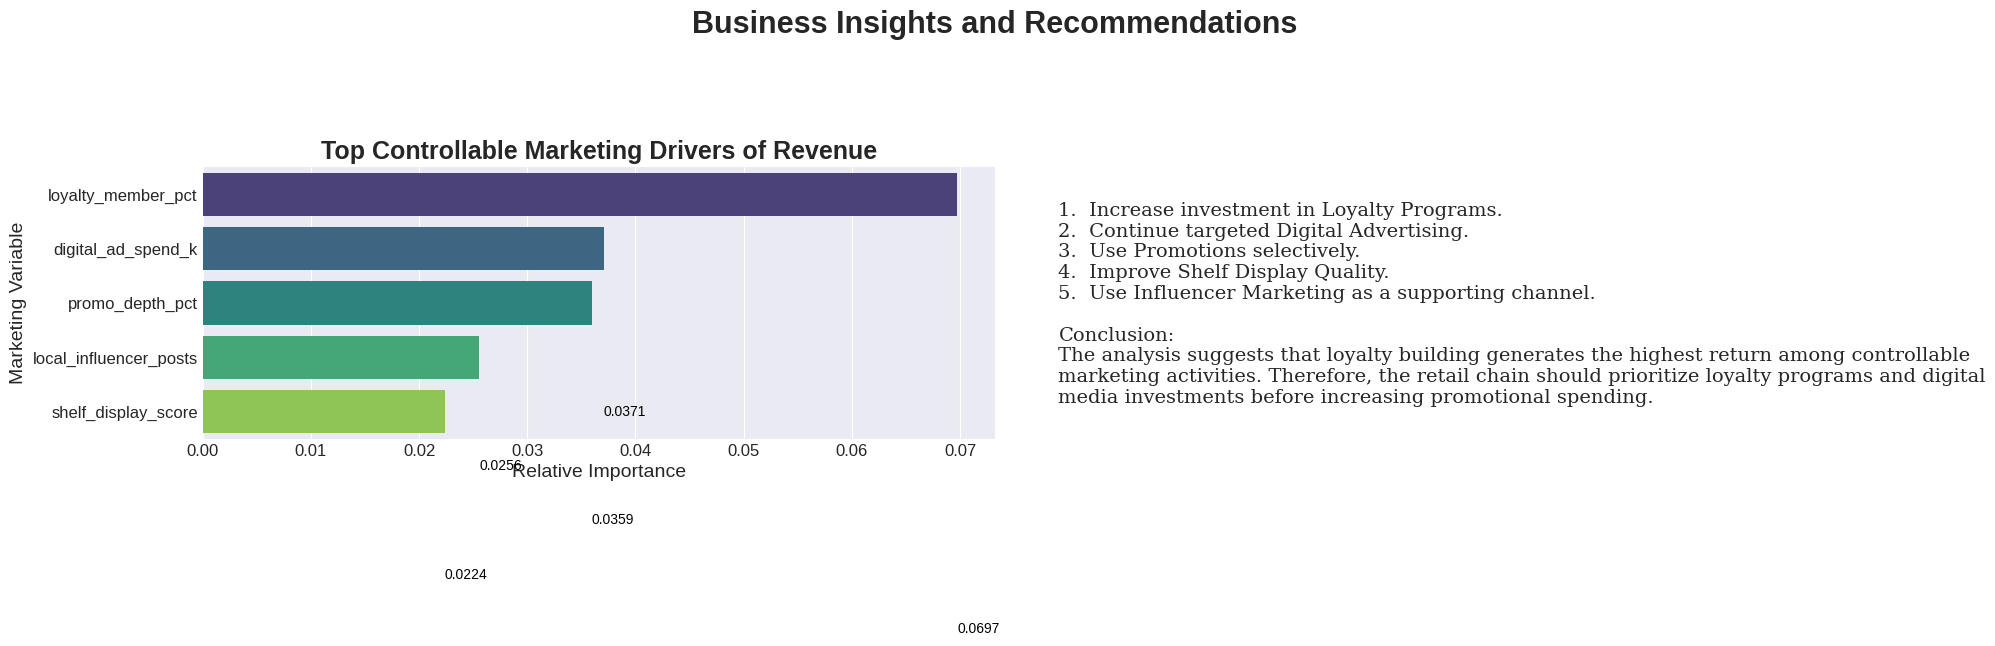

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set a professional style for the plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('viridis')

# Create a figure with two subplots: one for the bar chart and one for text
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 10))

# --- Plot 1: Top Controllable Marketing Drivers ---
sns.barplot(
    data=marketing_importance,
    x='Importance',
    y='Feature',
    ax=axes[0],
    hue='Feature', # Assign y to hue to resolve FutureWarning
    legend=False,  # Hide legend as it's redundant with y-axis labels
    palette='viridis' # Use the same color palette
)
axes[0].set_title('Top Controllable Marketing Drivers of Revenue', fontsize=18, fontweight='bold')
axes[0].set_xlabel('Relative Importance', fontsize=14)
axes[0].set_ylabel('Marketing Variable', fontsize=14)
axes[0].tick_params(labelsize=12)

# Annotate bars with importance values
for index, row in marketing_importance.iterrows():
    axes[0].text(row['Importance'], index, f'{row['Importance']:.4f}', color='black', ha='left', va='center', fontsize=10)

# --- Plot 2: Managerial Recommendations (Text) ---
axes[1].axis('off') # Hide axes for the text subplot

recommendation_text = '''
1.  Increase investment in Loyalty Programs.
2.  Continue targeted Digital Advertising.
3.  Use Promotions selectively.
4.  Improve Shelf Display Quality.
5.  Use Influencer Marketing as a supporting channel.

Conclusion:
The analysis suggests that loyalty building generates the highest return among controllable marketing activities. Therefore, the retail chain should prioritize loyalty programs and digital media investments before increasing promotional spending.
'''

axes[1].text(0.05, 0.95, recommendation_text,
             horizontalalignment='left',
             verticalalignment='top',
             transform=axes[1].transAxes,
             fontsize=14,
             fontfamily='serif',
             wrap=True)

fig.suptitle('Business Insights and Recommendations', y=1.02, fontsize=22, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()